<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Ciencias-planetarias/proyecto_planetarias_try_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
gat=!pip install gatspy
pyast=!pip install PyAstronomy


In [ ]:
pytrans=!pip install pytransit
cel=!pip install celerite



In [ ]:
#Librerias necesarias:

from __future__ import print_function
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#from astropy.stats.lombscargle import LombScargle
from google.colab import files
from astropy.timeseries import LombScargle
from gatspy import datasets, periodic
from PyAstronomy.modelSuite import KeplerRVModel
from PyAstronomy import funcFit as fuf

from astropy.time import Time
from datetime import datetime

%matplotlib inline

carga de datos

In [ ]:
# subir datos
fils = files.upload()

Saving sloan_photo_wasp4b.txt to sloan_photo_wasp4b.txt
Saving rraw_phase_photo_wasp4b.txt to rraw_phase_photo_wasp4b.txt
Saving cousins_photo_wasp4b.txt to cousins_photo_wasp4b.txt
Saving raw_vr_wasp4b.txt to raw_vr_wasp4b.txt
Saving error_fase_vr_wasp4b.txt to error_fase_vr_wasp4b.txt
Saving fase_vr_wasp4b.txt to fase_vr_wasp4b.txt


lectura de datos

In [ ]:
# Leer datos con pandas # datos.keys() # nombres de columnas
# fotometria

datos_photo_sloan = pd.read_csv('sloan_photo_wasp4b.txt', delim_whitespace=True)
datos_photo_raw = pd.read_csv('rraw_phase_photo_wasp4b.txt', delim_whitespace=True)
datos_photo_cousins = pd.read_csv('cousins_photo_wasp4b.txt', delim_whitespace=True)

# vel radial
datos_vr     = pd.read_csv('fase_vr_wasp4b.txt', delim_whitespace=True)
err_datos_vr = pd.read_csv('error_fase_vr_wasp4b.txt', delim_whitespace=True)

datos_vr_raw = pd.read_csv('raw_vr_wasp4b.txt', delim_whitespace=True)


In [ ]:
datos_photo_sloan.keys()

Index(['BJD', 'Relative_Flux', 'Relative_Flux_Uncertainty', 'Accepted'], dtype='object')

In [ ]:
1

-2454696.700127

In [ ]:
# JD_1 = np.array(datos_photo['BJD'])-2400000                                     # Barycentric Julian date of observation
mag      = np.array(datos_photo_raw['Differential_Magnitude'])                  # Magnitud
fase_mag = np.array(datos_photo_raw['Phase'])                                   # Magnitud

hjd_mag_cousins   = np.array(datos_photo_cousins['HJD'])  -datos_photo_cousins['HJD'][0]              # dia juliano baricentro
mag_cousins      = np.array(datos_photo_cousins['Differential_Magnitude'])         # Magnitud
err_mag_cousins = np.array(datos_photo_cousins['Differential_Magnitude_Uncertainty']) # error de magnitud

bjd_flux_sloan   = np.array(datos_photo_sloan['BJD'])   -datos_photo_sloan['BJD'][0]               # dia juliano heliocentro
flux_sloan      = np.array(datos_photo_sloan['Relative_Flux'])                    # flujo
err_flux_sloan = np.array(datos_photo_sloan['Relative_Flux_Uncertainty'])          # error de flujo


# velocidad radial
phase_vr = np.array(datos_vr['Phase'])*1.3382315 # fase dias correcion periodo
rad_vel  = np.array(datos_vr['Radial_Velocity']) # fase [m/s]
err_rv   = np.array(err_datos_vr['Radial_Velocity_Uncertainty']) # fase [m/s]

jd_vr_raw   = np.array(datos_vr_raw['BJD'])#*1.3382315 # fase dias correcion periodo
rad_vel_raw = np.array(datos_vr_raw['Radial_Velocity']) # fase [m/s]
err_rv_raw  = np.array(datos_vr_raw['Radial_Velocity_Uncertainty']) # fase [m/s]

In [ ]:
#Normalizamos utilizando la media: CREO QUE NO TOCA USAR ESTO
rad_vel = rad_vel - rad_vel.mean()
err_rv = err_rv - err_rv.mean()

rad_vel_raw = rad_vel_raw - rad_vel_raw.mean()
err_rv_raw  = err_rv_raw - err_rv_raw.mean()

# **Velocidad radial**

In [ ]:
# fiteo radial
from scipy.interpolate import UnivariateSpline # splin ciego

# orden para fiteo
x_ord, y_ord = zip( *sorted( zip(phase_vr, rad_vel) ) )

fit = UnivariateSpline(x_ord, y_ord, s=14000)
x = np.linspace(x_ord[0], x_ord[-1], 1000)

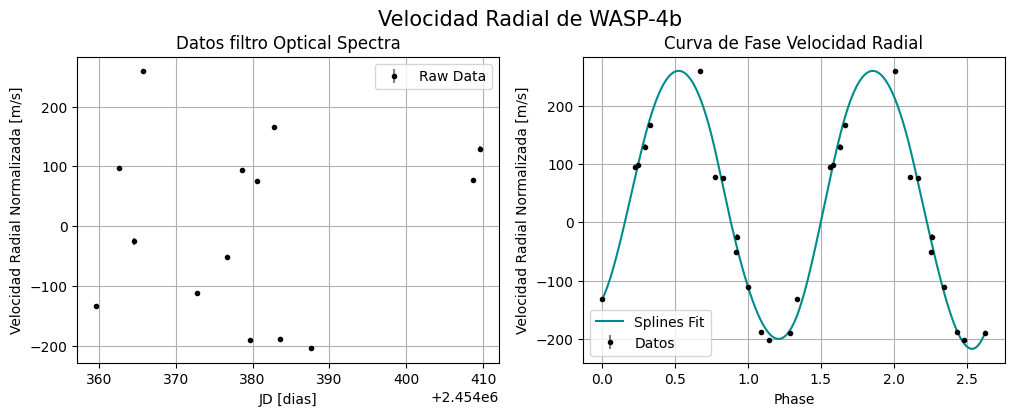

In [ ]:
# FIGURA VELOCIDAD RADIAL
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
fig.suptitle('Velocidad Radial de WASP-4b', fontsize=15)
fig.tight_layout(w_pad=3)
ax0 = ax[0]; ax1 = ax[1]


ax0.errorbar(jd_vr_raw, rad_vel_raw, yerr = np.abs(err_rv_raw), fmt='.',c='k',ecolor='gray', label='Raw Data')
ax0.grid()
ax0.legend()
ax0.set(title='Datos filtro Optical Spectra',
        xlabel='JD [dias]',
        ylabel='Velocidad Radial Normalizada [m/s]');

ax1.plot(x, fit(x), '#008B8B', label='Splines Fit') # splines ciegos
ax1.errorbar(phase_vr, rad_vel, yerr = np.abs(err_rv), fmt='.',c='k',ecolor='gray', label='Datos')
ax1.grid()
ax1.legend()
ax1.set(title='Curva de Fase Velocidad Radial',
        xlabel='Phase',
        ylabel='Velocidad Radial Normalizada [m/s]');

In [ ]:
#Cargamos el periodograma LombScargle:
from gatspy.periodic import LombScargleFast

#Aplicamos el modelo a nuestros datos:
model_raw              = LombScargleFast().fit( jd_vr_raw, rad_vel_raw)#, np.abs(err_rv_raw))
periods_raw, power_raw = model_raw.periodogram_auto(nyquist_factor=100)


model          = LombScargleFast().fit( x, fit(x))#, err_rv)
periods, power = model.periodogram_auto(nyquist_factor=100)

/usr/local/lib/python3.10/dist-packages/gatspy/periodic/lomb_scargle_fast.py:429: UserWarning: For smaller datasets, the approximation used by LombScargleFast may not be suitable.
It is recommended to use LombScargle instead.
To silence this warning, set ``silence_warnings=True``
  warnings.warn("For smaller datasets, the approximation used by "


In [ ]:
# A partir de la serie de tiempo, damos un rango estimado donde podría estar el periodo:
model_raw.optimizer.period_range = (1, 1.5)
P_raw = model_raw.best_period
print("El periodo orbital RAW de WASP-4 B es: %.4f"% P_raw, "dias")


model.optimizer.period_range = (1, 1.5)
P = model.best_period
print("El periodo orbital de WASP-4 B es: %.4f"% P, "dias\n")


# Ponemos la masa de la estrella WASP-4:
M = 0.89 # Masas solares
P1 = P/365.25 #Periodo en años
P1_raw = P_raw/365.25 #Periodo en años

#Por la tercera ley de Kepler, calculamos el semieje mayor.
a = ((P1**2)*(M))**(1/3)        # Semi eje mayor en unidades astronómicas
a_raw = ((P1_raw**2)*(M))**(1/3) # Semi eje mayor en unidades astronómicas

print ("El semieje mayor RAW es %.4f"% a_raw, "UA")
print ("El semieje mayor es %.4f"% a, "UA")

# silence_warnings=True

Finding optimal frequency:
 - Estimated peak width = 0.126
 - Using 5 steps per peak; omega_step = 0.0252
 - User-specified period range:  1 to 1.5
 - Computing periods at 85 steps
Zooming-in on 5 candidate peaks:
 - Computing periods at 995 steps
El periodo orbital RAW de WASP-4 B es: 1.3374 dias
Finding optimal frequency:
 - Estimated peak width = 2.39
 - Using 5 steps per peak; omega_step = 0.478
 - User-specified period range:  0.96 to 1.5
 - Computing periods at 6 steps
Zooming-in on 5 candidate peaks:
 - Computing periods at 995 steps
El periodo orbital de WASP-4 B es: 1.3491 dias

El semieje mayor RAW es 0.0229 UA
El semieje mayor es 0.0230 UA


/usr/local/lib/python3.10/dist-packages/gatspy/periodic/lomb_scargle_fast.py:429: UserWarning: For smaller datasets, the approximation used by LombScargleFast may not be suitable.
It is recommended to use LombScargle instead.
To silence this warning, set ``silence_warnings=True``
  warnings.warn("For smaller datasets, the approximation used by "
/usr/local/lib/python3.10/dist-packages/gatspy/periodic/lomb_scargle_fast.py:429: UserWarning: For smaller datasets, the approximation used by LombScargleFast may not be suitable.
It is recommended to use LombScargle instead.
To silence this warning, set ``silence_warnings=True``
  warnings.warn("For smaller datasets, the approximation used by "
/usr/local/lib/python3.10/dist-packages/gatspy/periodic/lomb_scargle_fast.py:429: UserWarning: For smaller datasets, the approximation used by LombScargleFast may not be suitable.
It is recommended to use LombScargle instead.
To silence this warning, set ``silence_warnings=True``
  warnings.warn("For sm

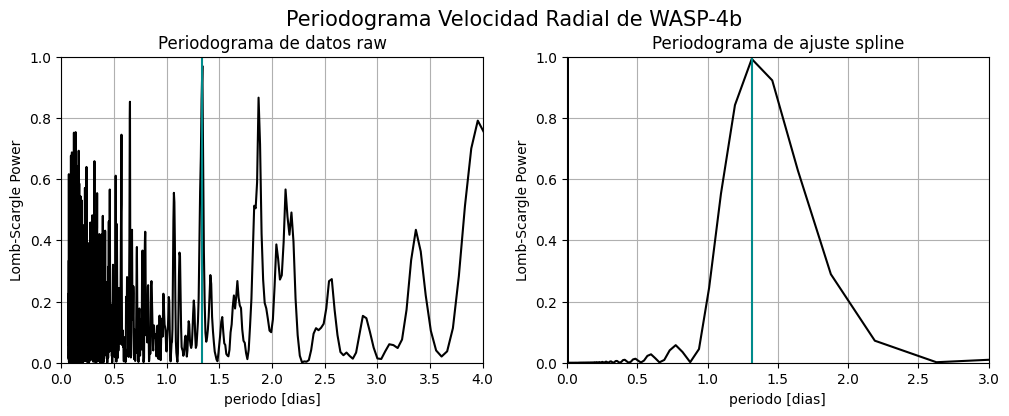

In [ ]:
#Graficamos
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
fig.suptitle('Periodograma Velocidad Radial de WASP-4b', fontsize=15)
fig.tight_layout(w_pad=3)
ax0 = ax[0]; ax1 = ax[1]

# data raw
ax0.plot(periods_raw, power_raw,'k')
ax0.vlines(P_raw, 0,1,'#008B8B')
ax0.grid()
ax0.set(xlim=(0, 4), ylim=(0, 1),
       title= 'Periodograma de datos raw',
       xlabel='periodo [dias]',
       ylabel='Lomb-Scargle Power');

# data fiteada
ax1.plot(periods, power,'k')
ax1.vlines(1.3374-0.02, 0,1,'#008B8B')# ax1.vlines(P, 0,1)
ax1.grid()
ax1.set(xlim=(0, 3), ylim=(0, 1),
       title= 'Periodograma de ajuste spline',
       xlabel='periodo [dias]',
       ylabel='Lomb-Scargle Power');

In [ ]:
#Aquí, obtenemos la semiamplitud de velocidad radial.

K = (max(fit(x))-min(fit(x)))/2
print("La semiamplitud resultante es de: %.3f"% K ,"m/s")

# Tomamos la ecuación de la masa mínima en unidades canónicas, obteniendo así:
ex = 0

mpsin =((K)/(28.4329))*((M)**(2./3.))*((P_raw/365.)**(1./3.))*(np.sqrt(1-ex))
print("La masa mínima es: %.4f"%mpsin, "Mj")

mp_real =1.216 #±0.013
i_real = 87.63 #+0.32-0.28
mpsin_real = mp_real* np.sin(i_real*(np.pi/180))
mp = mpsin/np.sin(i_real*(np.pi/180))

print("La masa obtenida es: ", mp, "Mj\n")
print("La masa real seria: %.4f"%mp_real, "Mj")
print("La masa mínima real seria: %.4f"%mpsin_real, "Mj")

err_abs= np.abs(mpsin_real-mpsin)
err_porc = 100*err_abs/mpsin_real
print('\nel error absoluto en la masa minima:', err_abs)
print('el error porcentual en la masa minima:', err_porc)


err_abs_1= np.abs(mp_real-mp)
err_porc_1 = 100*err_abs/mp_real
print('\nel error absoluto en la masa minima:', err_abs_1)
print('el error porcentual en la masa minima:', err_porc_1)

La semiamplitud resultante es de: 238.556 m/s
La masa mínima es: 1.1968 Mj
La masa obtenida es:  1.19780724226844 Mj

La masa real seria: 1.2160 Mj
La masa mínima real seria: 1.2150 Mj

el error absoluto en la masa minima: 0.018177195995556783
el error porcentual en la masa minima: 1.4961149450296016

el error absoluto en la masa minima: 0.018192757731559928
el error porcentual en la masa minima: 1.494835197003025


# **Transito**

In [ ]:
# orden para fiteo
x_ord_photo, y_ord_photo = zip( *sorted( zip(fase_mag, mag) ) )

# x_ord_photo, y_ord_photo = zip( *sorted( zip(fase_mag, mag) ) )


fit_phot_raw = UnivariateSpline(x_ord_photo, y_ord_photo, s=10)
x_photo_raw  = np.linspace(0.0, 0.25, 1000)

# fit_phot_cousins = UnivariateSpline(hjd_mag_cousins, mag_cousins, s=100000)
# x_photo_cousins  = np.linspace(hjd_mag_cousins[30], hjd_mag_cousins[-90], 100)

# fit_phot_sloan = UnivariateSpline(bjd_flux_sloan, flux_sloan, s=1)
# x_photo_sloan  = np.linspace(bjd_flux_sloan[0], bjd_flux_sloan[50], 100)

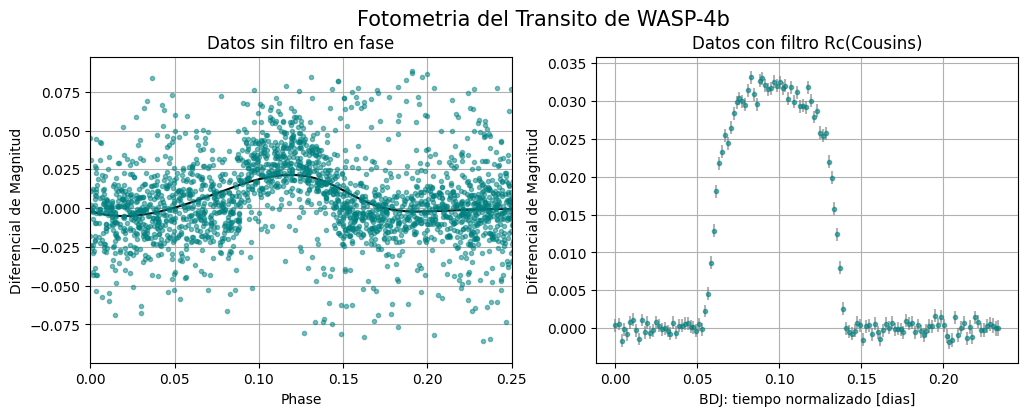

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
fig.suptitle('Fotometria del Transito de WASP-4b', fontsize=15)
fig.tight_layout(w_pad=3)
ax0 = ax[0]; ax1 = ax[1]


ax0.plot(x_photo_raw, fit_phot_raw(x_photo_raw) ,'k')
ax0.errorbar(fase_mag , mag, fmt='.',c='#008080',ecolor='gray',alpha=.5)
ax0.grid()
ax0.set(xlim=(0,0.25),
       title= 'Datos sin filtro en fase',
       xlabel='Phase',
       ylabel='Diferencial de Magnitud');


# ax1.plot(x_photo_cousins, fit_phot_cousins(x_photo_cousins) ,'k')
ax1.errorbar(hjd_mag_cousins , mag_cousins, yerr=err_mag_cousins,fmt='.',c='#008080',ecolor='gray',alpha=.6)
ax1.grid()
ax1.set(#xlim=(0,0.25), ylim=(-0.2,0.2),
       title= 'Datos con filtro Rc(Cousins)',
       xlabel='BDJ: tiempo normalizado [dias]',
       ylabel='Diferencial de Magnitud');

In [ ]:
bat=!pip install batman-package


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for batman-package: filename=batman_package-2.4.9-cp310-cp310-linux_x86_64.whl size=229432 sha256=979f356a5624bdf93473732dca6c2e41ebaa0297f5a1c66cd395d77ff97c71fb
  Stored in directory: /root/.cache/pip/wheels/d4/29/f5/245cad7bd7dcb2d11fb9fb1e76a0862145bbaf7731ef9e379e
Successfully built batman-package


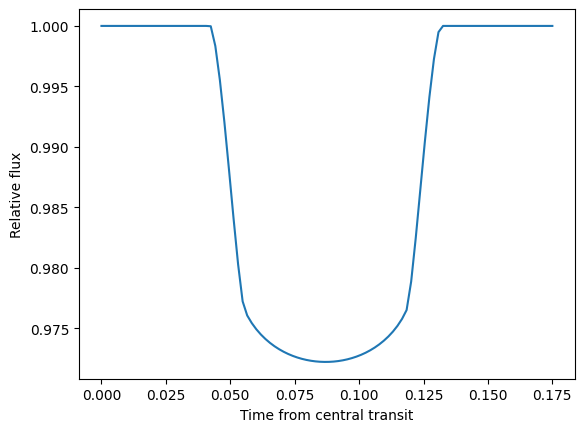

In [ ]:
import batman
import numpy as np
import matplotlib.pyplot as plt

params = batman.TransitParams()
params.t0 = 0.08699                     #time of inferior conjunction
params.per =  1.21#82315              #orbital period
params.rp = 0.158                     #planet radius (in units of stellar radii)
params.a = 4.915665                  #semi-major axis (in units of stellar radii)
params.inc = 87.                     #orbital inclination (in degrees)
params.ecc = 0.                      #eccentricity
params.w = 270.                       #longitude of periastron (in degrees)
params.u = [0.1, 0.3,0.1,-0.1]                #limb darkening coefficients [u1, u2]
params.limb_dark = "nonlinear"       #limb darkening model


t = np.linspace(0.0, 0.175, 100)

m = batman.TransitModel(params, t)    #initializes model
flux = m.light_curve(params)

plt.plot(t, flux)
plt.xlabel("Time from central transit")
plt.ylabel("Relative flux")
plt.show()

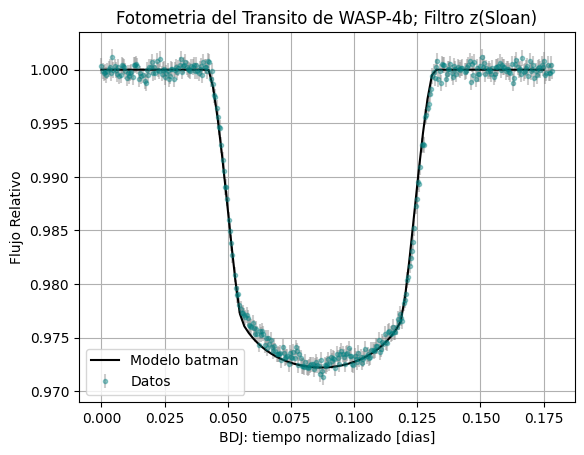

In [ ]:

plt.title('Fotometria del Transito de WASP-4b; Filtro z(Sloan)')
plt.errorbar(bjd_flux_sloan, flux_sloan, yerr=err_flux_sloan,fmt='.',c='#008080',ecolor='gray',alpha=.4,label='Datos')
plt.plot(t, flux,'k', label='Modelo batman')
plt.ylabel('Flujo Relativo')
plt.xlabel('BDJ: tiempo normalizado [dias]')
plt.grid()
plt.legend()

In [ ]:
R_star = 0.9188621 # radio estrella en radios solares

δ = (max(flux) - min(flux))/max(flux) # profundidad del transito
print('profundidad del transito', δ)

R_p_real=	1.364 #±0.029 radios de jupiter
print('Radio real del planeta', R_p_real, 'Rj')

# formula para encontrar el radio del planeta
R_p = np.sqrt(δ)*R_star # radio del planeta en radios solares
print('Radio del planeta', R_p, 'Rs')

R_pf = R_p * (696340/69911)
print('Radio del planeta', R_pf, 'Rj')

profundidad del transito 0.027794079022501417
Radio real del planeta 1.364 Rj
Radio del planeta 0.1531886125305617 Rs
Radio del planeta 1.5258165159922092 Rj


In [ ]:
err_abs_r = np.abs(R_p_real - R_pf)
err_porc_r = 100*err_abs_r/R_p_real
print('el error absoluto en el radio es:', err_abs_r)
print('el error porcentual en el radio es:', err_porc_r)

el error absoluto en el radio es: 0.16181651599220914
el error porcentual en el radio es: 11.863380937845244
